# Wikipedia Request for Adminship Analysis
## Community Structure, Voting Behavior, and Temporal Dynamics

---

### Project Overview

This project analyzes voting behavior in Wikipedia's *Requests for Adminship* (RfA) process using methods from:

- network science
- natural language processing
- tTemporal data analysis

The dataset contains voting interactions between Wikipedia users, including both the vote itself and the written justification accompanying each vote. Using this information, we construct voter agreement networks, identify communities using the Louvain algorithm, and investigate whether these communities differ in language use and temporal activity patterns.

---

## Research Questions

This project investigates the following questions:

1. Do voting communities emerge within Wikipedia administrator elections?
2. Are these communities associated with distinct linguistic patterns?
3. Are the detected communities driven by long-term temporal activity patterns?
4. How does community activity evolve over time?

---

# 1. Motivation

Wikipedia is one of the largest collaboratively maintained knowledge platforms in the world and plays a central role in the modern digital information ecosystem. Beyond being a popular online encyclopedia, Wikipedia has become an important source of training data for large language models and other AI systems. As a result, the individuals responsible for maintaining and governing Wikipedia indirectly influence how information is curated, presented, and consumed at a global scale.

One of the most important governance mechanisms on Wikipedia is the *Requests for Adminship* (RfA) process, where community members vote on whether a user should be granted administrator privileges. Administrators hold elevated permissions and are responsible for tasks such as moderating content, resolving conflicts, and enforcing community policies. Understanding how these decisions are made therefore provides insight into how authority, trust, and collaboration emerge within large online communities.

This project investigates whether distinct voting communities emerge within the RfA process and how these communities behave over time. In particular, we are interested in understanding:

- whether groups of users systematically vote together,
- whether these groups differ in the language they use,
- and whether detected communities are driven by stable social structures or temporary activity patterns.

The dataset is especially interesting from a computational social science perspective because it combines:

- social network structure,
- textual argumentation,
- and temporal activity data

within the same system.

By combining network analysis, natural language processing, and temporal analysis, the project aims to better understand how collaborative online governance systems organize themselves and how collective decision-making emerges in digital communities.

---

## Dataset Availability

The dataset used in this project is publicly available online as part of the Stanford Network Analysis Project (SNAP):

- https://snap.stanford.edu/data/wiki-RfA.html

Due to the size of the dataset, the raw data file is not included directly in the GitHub repository associated with this project. To reproduce the analysis, users must therefore download the dataset manually and place the file in the appropriate project directory before running the notebook.

The project was developed using the original text-based RfA dataset provided by SNAP.

---

# 2. Basic Statistics and Dataset Understanding

Before constructing the network and performing community analysis, it is important to understand the structure of the dataset and the preprocessing decisions that were made. Since the dataset combines both interaction data and textual information, careful preprocessing was necessary to ensure consistency across the different stages of analysis.

The original dataset is stored as a text file in which each vote is represented as a block of key-value pairs separated by blank lines. Each observation contains information about:

| Variable | Description |
|---|---|
| `SRC` | The user casting the vote |
| `TGT` | The user receiving the vote |
| `VOT` | The vote value (`1` = support, `-1` = oppose, `0` = neutral) |
| `RES` | Final election outcome |
| `YEA` | Year of the vote |
| `DAT` | Timestamp of the vote |
| `TXT` | Written vote justification |

To make the dataset usable for analysis, the raw text file was parsed into a structured list of Python dictionaries. Several preprocessing steps were then applied:

- malformed records with missing voters or candidates were removed,
- neutral votes (`VOT = 0`) were excluded from the agreement graph,
- usernames and text fields were normalized using string stripping,
- timestamps were converted into Python datetime objects,
- and voting relationships were aggregated into a projected voter-voter network.

Initially, the project experimented with a bipartite graph connecting voters and candidates directly. However, this representation was later replaced with a projected agreement graph in which two users are connected if they voted on the same candidate.

This projection allows the analysis to focus directly on relationships between voters rather than between voters and elections.

---

## 2.1 Constructing the Agreement Graph

The central network representation used throughout the project is a projected voter agreement graph. In this graph:

- each node represents a voter,
- and edges represent agreement relationships between voters.

Two users are connected if they voted on the same administrator candidate. The strength and direction of this relationship are determined by whether the users agreed or disagreed in their votes.

To construct the graph, votes were first grouped by candidate. For every pair of users who voted on the same candidate, an edge contribution was calculated using:

$$
w_{uv} = vote_u \cdot vote_v
$$

where:

- \(+1\) indicates agreement,
- and \(-1\) indicates disagreement.

This means that:
- two support votes increase agreement,
- two oppose votes also increase agreement,
- while opposing votes decrease agreement.

If two users voted together multiple times, their edge weight accumulated across all shared votes.

However, users who frequently participated in RfA discussions naturally accumulated larger edge weights simply due to repeated co-voting. To avoid the graph being dominated by highly active users rather than genuine agreement patterns, edge weights were normalized by the total number of shared votes between two users:

$$
\text{normalized agreement} =
\frac{\text{total agreement weight}}{\text{number of shared votes}}
$$

This normalization produces values between:

- \(+1\): complete agreement,
- \(0\): mixed voting behavior,
- and \(-1\): complete disagreement.

Finally, edges based on very few shared votes were later filtered in order to reduce noise and avoid accidental relationships created from isolated interactions.

---

## 2.2 Dataset Statistics

After preprocessing and graph construction, the dataset was transformed into a large-scale voter agreement network representing relationships between Wikipedia users based on shared voting behavior.

The dataset spans multiple years of Wikipedia administrator elections and contains both structural and textual information. This makes it possible to analyze:

- social interaction patterns,
- voting alignment,
- temporal activity,
- and written argumentation

within the same analytical framework.

The final agreement graph contains:

- **5106** nodes (voters)
- **498430** edges (agreement relationships)

after filtering weak relationships based on very few shared votes.

In addition to the full agreement graph, a filtered single-year graph for 2013 was also constructed in order to investigate whether detected communities were driven by long-term temporal separation or whether similar structures also emerged within shorter time periods.

Community detection was performed using the Louvain algorithm, which identified several voting communities within both the full graph and the 2013 subgraph.

The dataset also contains a large corpus of written voting justifications. These texts were later aggregated by community and analyzed using TF-IDF and visualization techniques such as word clouds in order to investigate whether communities differed linguistically.

---

### Text Cleaning and Preprocessing

Before performing textual analysis, the vote justification texts were cleaned and normalized in order to reduce noise and remove formatting artifacts originating from Wikipedia markup.

The preprocessing pipeline included the following steps:

- conversion to lowercase,
- removal of Wikipedia link syntax,
- removal of HTML/XML-style tags,
- removal of repeated apostrophe formatting used for bold/italic markup,
- removal of URLs,
- removal of non-alphabetic characters,
- tokenization using whitespace splitting,
- removal of stopwords,
- and removal of very short tokens.

Regular expressions were used extensively during this process to identify and remove formatting patterns specific to Wikipedia text. This preprocessing step was necessary to ensure that later analyses such as TF-IDF and word cloud generation focused on meaningful semantic content rather than markup and structural noise.

The cleaned texts were then aggregated by community in order to compare linguistic patterns between detected voting groups.

---

Finally, temporal information from vote timestamps was used to analyze how community activity evolved over time both across the full dataset and within the 2013 subgraph.

---

# 3. Tools, Theory, and Analysis

This project combines methods from network science, natural language processing, and temporal data analysis in order to investigate how voting communities emerge within Wikipedia’s Requests for Adminship process.

The analysis was designed as a multi-step pipeline in which both structural and textual information were used to understand the behavior of users within the network. Rather than relying on a single analytical method, the project combines several complementary approaches:

- graph construction and network projection,
- community detection,
- temporal activity analysis,
- and text-based analysis using TF-IDF and visualization techniques.

The overall workflow of the project can be summarized as follows:

1. Parse and preprocess the raw RfA dataset.
2. Construct a projected voter agreement graph.
3. Normalize and filter agreement relationships.
4. Detect voting communities using the Louvain algorithm.
5. Analyze textual patterns within communities.
6. Investigate whether communities persist across time.
7. Compare activity patterns between communities.

The following sections describe the theoretical motivation behind these methods and how they were applied throughout the project.

---

For the very first step, we imported all Python packages that would be useful and necessary for this project:

In [1]:
import networkx as nx
import json
from networkx.readwrite import json_graph
from collections import defaultdict
from itertools import combinations
import numpy as np
import matplotlib.pyplot as plt
from community import community_louvain
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
import re
import pandas as pd
from wordcloud import WordCloud
import math
import matplotlib.cm as cm
from pathlib import Path
import matplotlib.colors as mcolors
from collections import Counter

Create function to load data in a proper format

In [2]:
def parse_rfa(file_path):
    with open(file_path, 'rt', encoding='utf-8') as f:
        content = f.read()

    entries = content.strip().split("\n\n")
    data = []

    for entry in entries:
        record = {}
        for line in entry.split("\n"):
            if ":" in line:
                key, value = line.split(":", 1)
                record[key.strip()] = value.strip()
        data.append(record)

    return data

Create a function that builds the graph

In [3]:
def build_voter_graph(data):
    votes_by_candidate = defaultdict(list)

    for d in data:
        src = d.get("SRC", "").strip()
        tgt = d.get("TGT", "").strip()

        if not src or not tgt:
            continue

        vote = int(d["VOT"])

        # skip neutral votes
        if vote == 0:
            continue

        votes_by_candidate[tgt].append((src, vote))

    G = nx.Graph()

    for cand, voter_list in votes_by_candidate.items():
        for (u, vote_u), (v, vote_v) in combinations(voter_list, 2):

            pair_weight = vote_u * vote_v  # +1 agreement, -1 disagreement

            if G.has_edge(u, v):
                G[u][v]["weight"] += pair_weight
                G[u][v]["count"] += 1
            else:
                G.add_edge(u, v, weight=pair_weight, count=1)
        
    for u, v, data in G.edges(data=True):
        data["normalized"] = round(data["weight"] / data["count"], 5)

    return G

Build the graph and check for amount of nodes and edges

In [4]:
data = parse_rfa("wiki-RfA.txt")
G = build_voter_graph(data)

print("Voter graph:")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

print(list(G.edges(data=True))[:10])

Voter graph:
Nodes: 10283
Edges: 3055279
[('Steel1943', 'Cuchullain', {'weight': 1, 'count': 1, 'normalized': 1.0}), ('Steel1943', 'INeverCry', {'weight': 1, 'count': 1, 'normalized': 1.0}), ('Steel1943', 'Cncmaster', {'weight': 1, 'count': 1, 'normalized': 1.0}), ('Steel1943', 'Miniapolis', {'weight': 0, 'count': 2, 'normalized': 0.0}), ('Steel1943', 'Sven Manguard', {'weight': 1, 'count': 1, 'normalized': 1.0}), ('Steel1943', 'Ramaksoud2000', {'weight': 1, 'count': 1, 'normalized': 1.0}), ('Steel1943', 'RockMagnetist', {'weight': 1, 'count': 1, 'normalized': 1.0}), ('Steel1943', 'Carrite', {'weight': 1, 'count': 1, 'normalized': 1.0}), ('Steel1943', 'Someguy1221', {'weight': 1, 'count': 1, 'normalized': 1.0}), ('Steel1943', 'Secret', {'weight': 0, 'count': 2, 'normalized': 0.0})]


Saves graph as .json file

In [5]:
proj = json_graph.node_link_data(G)

with open("voter_graph.json", "w") as f:
    json.dump(proj, f)

Amount of edges appears to be far too big. Checking for distribution and percentiles of counts

In [6]:
# distribution of counts
counts = [d["count"] for _, _, d in G.edges(data=True)]

print("Min:", min(counts))
print("Max:", max(counts))
print("Average:", sum(counts)/len(counts))

# percentiles
counts = np.array([d["count"] for _, _, d in G.edges(data=True)])

print("Percentiles:")
for p in [50, 75, 80, 90, 95, 99]:
    print(f"{p}th percentile:", np.percentile(counts, p))

Min: 1
Max: 672
Average: 3.5340612101218905
Percentiles:
50th percentile: 1.0
75th percentile: 3.0
80th percentile: 4.0
90th percentile: 7.0
95th percentile: 12.0
99th percentile: 35.0


Appears to be a lot of noise among the edges with a small number of co-votes. Decides to create a threshold of 4 minimum co-votes to create an edges to avoid creating a graph that is too big and noisy

Creates 2 filtered graphs: G_agree for co-voters with mostly agreement, and G_disagree for co-voters with mostly disagreement

In [7]:
G_agree = nx.Graph()
G_disagree = nx.Graph()

for u, v, data in G.edges(data=True):
    c = data["count"]
    n = data["normalized"]
    w = data["weight"]

    # Keep only edges with enough evidence
    if c < 4:
        continue

    # Agreement graph
    if n > 0:
        G_agree.add_edge(
            u,
            v,
            count=c,
            weight=w,
            normalized=n,
            community_weight=n
        )

    # Disagreement graph
    elif n < 0:
        G_disagree.add_edge(
            u,
            v,
            count=c,
            weight=abs(w),
            normalized=n,
            community_weight=abs(n)
        )

print("Agree graph:")
print("Nodes:", G_agree.number_of_nodes())
print("Edges:", G_agree.number_of_edges())

print("\nDisagree graph:")
print("Nodes:", G_disagree.number_of_nodes())
print("Edges:", G_disagree.number_of_edges())

Agree graph:
Nodes: 5106
Edges: 498430

Disagree graph:
Nodes: 4317
Edges: 105995


Save agreement graph

In [8]:
agree = json_graph.node_link_data(G_agree)

with open("agree_graph.json", "w", encoding="utf-8") as f:
    json.dump(agree, f)

Save disagreement graph

In [9]:
disagree = json_graph.node_link_data(G_disagree)

with open("disagree_graph.json", "w", encoding="utf-8") as f:
    json.dump(disagree, f)

Basic statistics of agreement graph

In [10]:
def graph_stats(G, name):
    degrees = [d for _, d in G.degree()]
    weights = [d["normalized"] for _, _, d in G.edges(data=True)]
    counts  = [d["count"]      for _, _, d in G.edges(data=True)]
    print(f"--- {name} ---")
    print(f"  Nodes:              {G.number_of_nodes()}")
    print(f"  Edges:              {G.number_of_edges()}")
    print(f"  Avg degree:         {np.mean(degrees):.2f}")
    print(f"  Max degree:         {max(degrees)}")
    print(f"  Avg |norm weight|:  {np.mean(np.abs(weights)):.4f}")
    print(f"  Avg co-vote count:  {np.mean(counts):.2f}")
    print(f"  Max co-vote count:  {max(counts)}")
    print()

graph_stats(G_agree, "Agreement")

--- Agreement ---
  Nodes:              5106
  Edges:              498430
  Avg degree:         195.23
  Max degree:         2691
  Avg |norm weight|:  0.6587
  Avg co-vote count:  12.34
  Max co-vote count:  672



Community detection for agreement graph with a fixed random seed for reproducibility

In [11]:
partition_agree = community_louvain.best_partition(
    G_agree,
    weight="community_weight",
    random_state=42
)

Basic summary

In [12]:
num_communities = len(set(partition_agree.values()))
print("Number of communities:", num_communities)

community_sizes = Counter(partition_agree.values())
print("\nLargest communities:")
for comm, size in community_sizes.most_common(10):
    print(f"Community {comm}: {size} nodes")

Number of communities: 6

Largest communities:
Community 5: 1694 nodes
Community 2: 1318 nodes
Community 3: 1085 nodes
Community 0: 991 nodes
Community 4: 14 nodes
Community 1: 4 nodes


Attach community labels to the graph

In [13]:
nx.set_node_attributes(G_agree, partition_agree, "community")

Save graph with communites

In [14]:
com = json_graph.node_link_data(G_agree)

with open("agree_graph_communities.json", "w", encoding="utf-8") as f:
    json.dump(com, f)

Checking if all voters have been assigned to a community

In [15]:
node_to_community = {
    node: attrs["community"]
    for node, attrs in G_agree.nodes(data=True)
    if "community" in attrs
}

print("Nodes with community labels:", len(node_to_community))

Nodes with community labels: 5106


Checking how many texts there are in total

In [16]:
def parse_rfa(file_path):
    with open(file_path, "rt", encoding="utf-8") as f:
        content = f.read()

    entries = content.strip().split("\n\n")
    data = []

    for entry in entries:
        record = {}
        for line in entry.split("\n"):
            if ":" in line:
                key, value = line.split(":", 1)
                record[key.strip()] = value.strip()
        data.append(record)

    return data

records = parse_rfa("wiki-RfA.txt")
print("Records:", len(records))

Records: 198275


Checking for each community

In [17]:
texts_by_community = defaultdict(list)

for r in records:
    src = r.get("SRC")
    txt = r.get("TXT", "").strip()

    if not txt:
        continue

    if src in node_to_community:
        comm = node_to_community[src]
        texts_by_community[comm].append(txt)

for comm, texts in texts_by_community.items():
    print(f"Community {comm}: {len(texts)} texts")

Community 0: 32894 texts
Community 2: 47914 texts
Community 5: 63989 texts
Community 3: 38739 texts
Community 4: 39 texts
Community 1: 10 texts


Appears to be a sufficient amount for the 4 largest communities, but not so much for the 2 small ones. Will keep this in mind when analyzing TF-IDF and Wordclouds

Defines each community to be 1 document

In [18]:
community_ids = sorted(texts_by_community.keys())
community_documents = [
    " ".join(texts_by_community[comm])
    for comm in community_ids
]

print("Number of community documents:", len(community_documents))

Number of community documents: 6


Defines stopwords for filtering

In [19]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/andreasstampedalgaard/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Defines additional custom stopwords to remove noise

In [55]:
custom_stopwords = {
    "support", "oppose", "neutral",
    "wikipedia", "wiki", "user", "editor",
    "admin", "candidate", "rfa",
    "vote", "voted", "voting",
    "page", "article",
    "would", "could", "should", "also",
    "one", "two", "well", "like", "think",
    "see", "really", "much", "many",
    "per", "however", "since",
    "make", "made",
    "nbsp", "mdash", "ndash", "nom",
    "afd", "mos", "jasper", "deng", "mkdw"
}

all_stopwords = stop_words.union(custom_stopwords)

Creates a function to filter text to remove noise, mistakes, errors, links, weird symbols and the likes

In [21]:
def clean_text(text):
    text = text.lower()
    
    text = re.sub(r"\[\[.*?\]\]", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"'{2,}", " ", text)
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    
    tokens = text.split()
    
    tokens = [
        w for w in tokens
        if w not in all_stopwords and len(w) > 2
    ]
    
    return " ".join(tokens)

Applies function to documents

In [22]:
community_documents = [
    " ".join(clean_text(t) for t in texts_by_community[c])
    for c in community_ids
]

Calculates TF-IDF and saves in DataFrame

In [23]:
vectorizer = TfidfVectorizer(
    stop_words=None,
    max_df=0.9,
    min_df=1,
    ngram_range=(1, 2)        
)

X = vectorizer.fit_transform(community_documents)
terms = vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(
    X.toarray(),
    index=[f"community_{c}" for c in community_ids],
    columns=terms
)

Finds top TF-IDF words for each community

In [24]:
for comm in community_ids:
    row = tfidf_df.loc[f"community_{comm}"]
    top_terms = row.sort_values(ascending=False).head(20)

    print(f"\nTop TF-IDF terms for community {comm}:")
    for term, score in top_terms.items():
        print(f"{term}: {score:.4f}")


Top TF-IDF terms for community 0:
work: 0.2784
tools: 0.2282
experience: 0.2270
time: 0.1704
concerns: 0.1669
edits: 0.1653
content: 0.1469
contributions: 0.1403
enough: 0.1375
answers: 0.1345
seems: 0.1264
great: 0.1245
questions: 0.1133
areas: 0.1129
months: 0.1025
seen: 0.1020
answer: 0.1014
reason: 0.1012
need: 0.1003
project: 0.0987

Top TF-IDF terms for community 1:
ghirlandajo: 0.2350
alex: 0.2174
rights: 0.1305
contributors: 0.1305
alex bakharev: 0.1007
bakharev: 0.1007
disputes: 0.0870
willing: 0.0870
russian: 0.0870
trolls: 0.0870
insulted: 0.0870
wars wishing: 0.0849
giving ghirlandajo: 0.0849
anonymous trolls: 0.0849
wanting posess: 0.0849
alex nice: 0.0849
users insulted: 0.0849
users contributors: 0.0849
unwilling provoke: 0.0849
alex division: 0.0849

Top TF-IDF terms for community 2:
tools: 0.2922
work: 0.2394
experience: 0.2354
edits: 0.1907
time: 0.1641
great: 0.1399
enough: 0.1360
concerns: 0.1244
contributions: 0.1232
seems: 0.1202
answers: 0.1193
project: 0.1117
n

Creates wordclouds for each community

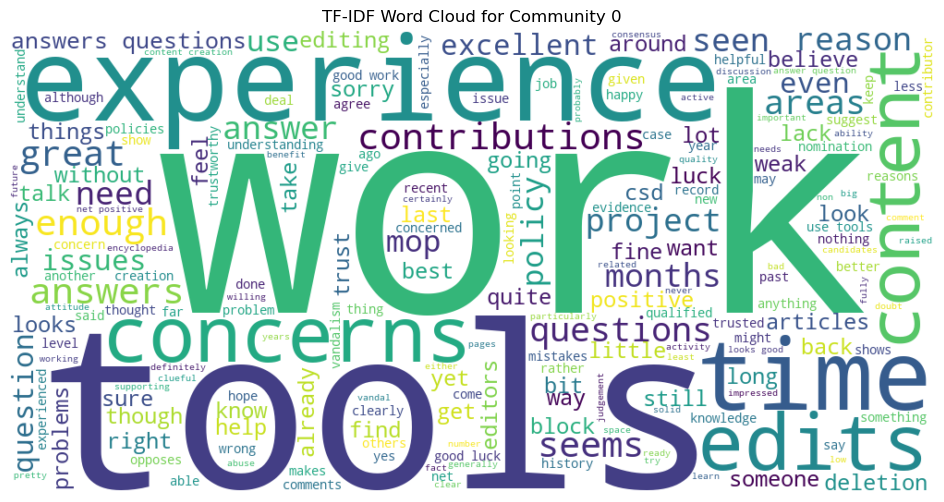

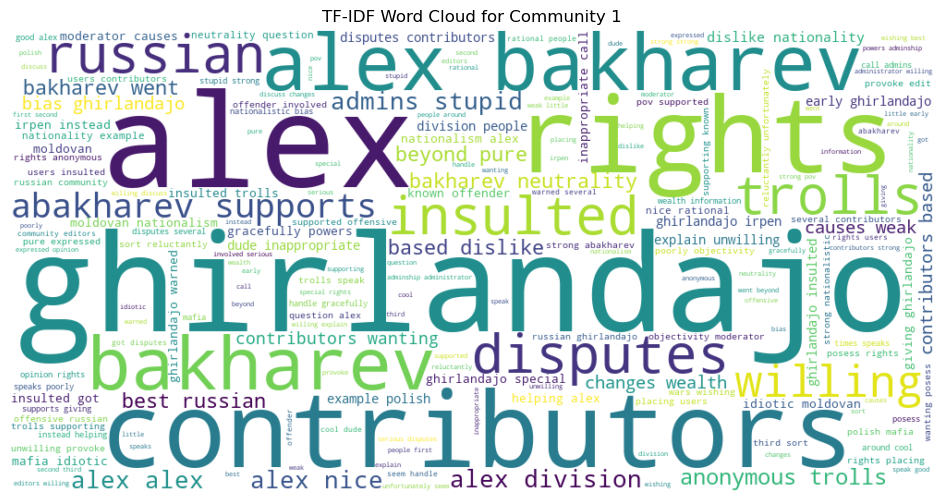

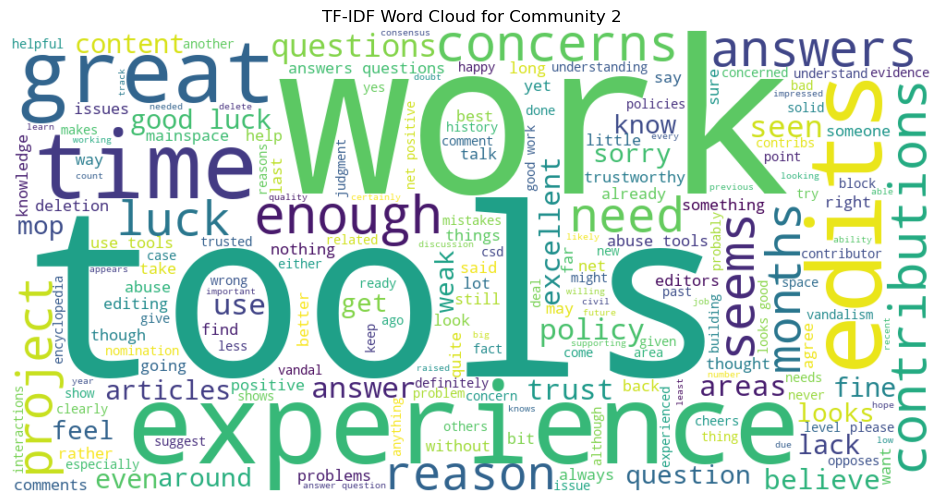

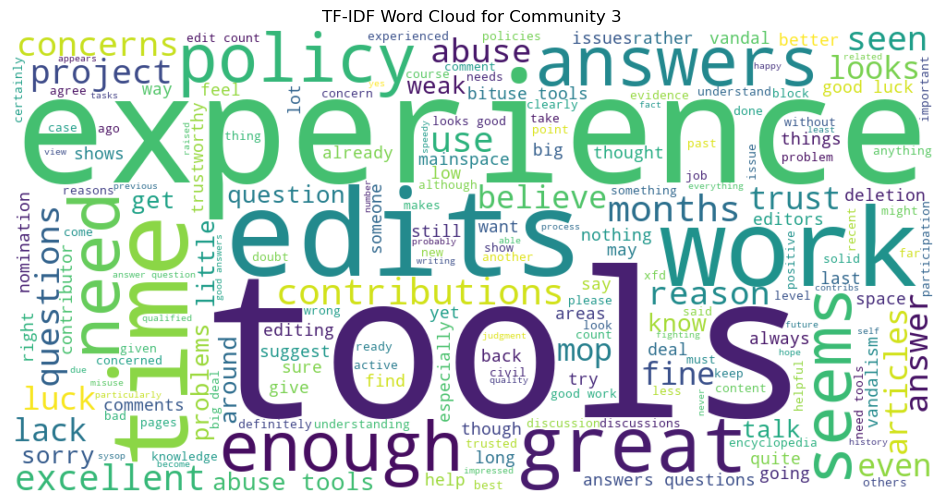

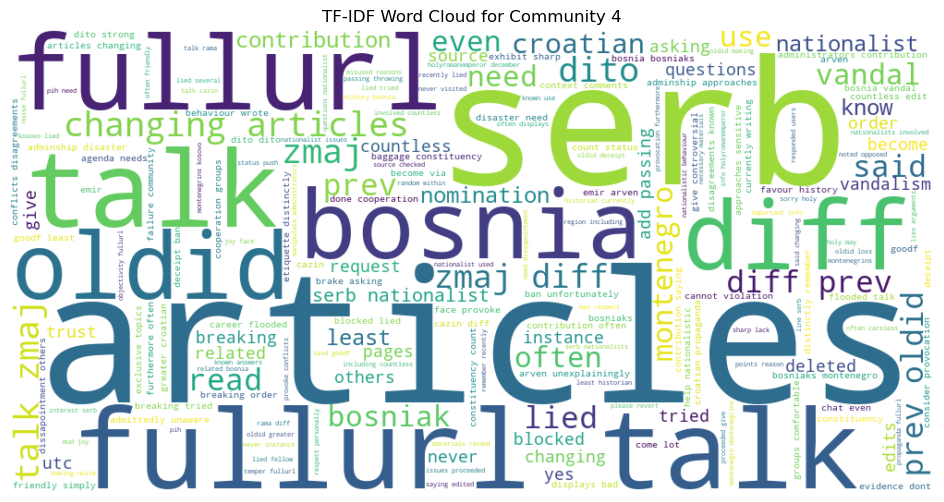

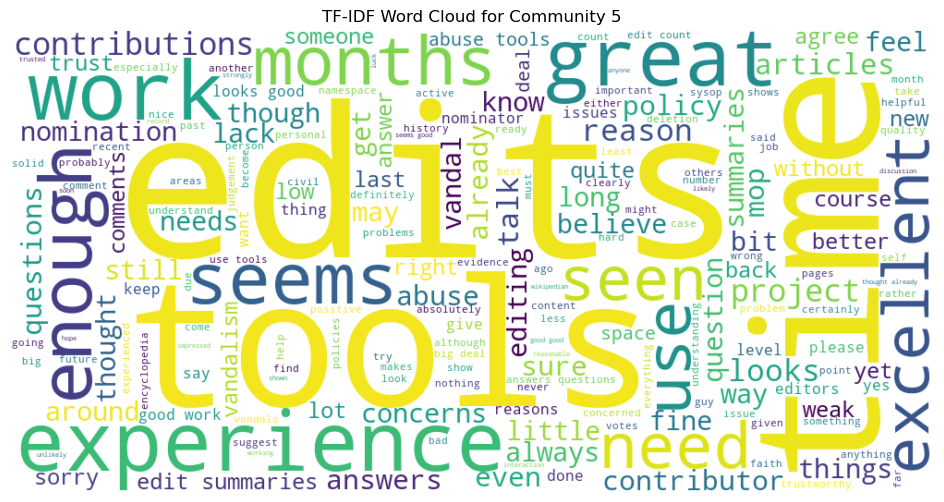

In [ ]:
for c in community_ids:
    row = tfidf_df.loc[f"community_{c}"]
    
    freq_dict = row[row > 0].to_dict()

    wc = WordCloud(
        width=1000,
        height=500,
        background_color="white"
    ).generate_from_frequencies(freq_dict)

    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"TF-IDF Word Cloud for Community {c}")
    plt.savefig(f"community_{c}_wordcloud.png", dpi=150)
    plt.show()

Top 4 communites seems to share their top TF-IDF words, which all seem realistic. The 2 small communites appear to have very wierd and random words, which is most likely due to their small size and limited amount of texts. Considers only focusing on top 4 communities from here

Community summary

/var/folders/sl/435gx6y958q0v8qp_2lgbcww0000gn/T/ipykernel_56926/2401226340.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", len(community_ids))


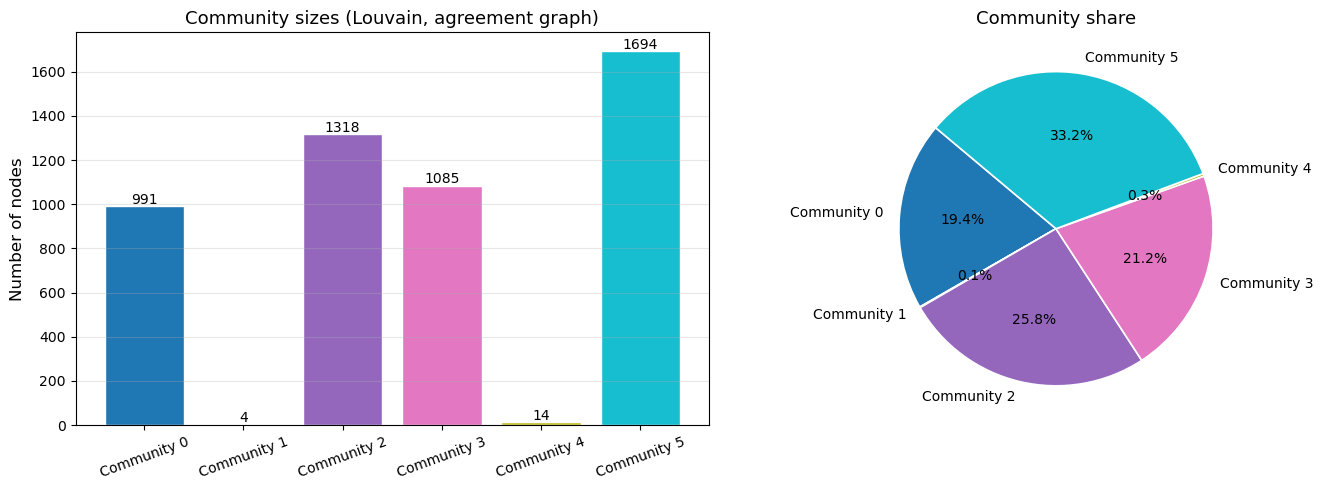


Average normalized weight within each community:
  Community 0: 0.6894 (over 67847 intra-community edges)
  Community 1: 1.0000 (over 6 intra-community edges)
  Community 2: 0.6424 (over 86348 intra-community edges)
  Community 3: 0.6852 (over 43275 intra-community edges)
  Community 4: 1.0000 (over 80 intra-community edges)
  Community 5: 0.7048 (over 117775 intra-community edges)


In [26]:
# Pull community labels from node attributes
partition = nx.get_node_attributes(G_agree, "community")
community_ids = sorted(set(partition.values()))

# Map community IDs to colours (tab10 palette)
cmap = cm.get_cmap("tab10", len(community_ids))
COMM_COLORS = {c: mcolors.to_hex(cmap(i)) for i, c in enumerate(community_ids)}

# Sizes
sizes = Counter(partition.values())
labels = [f"Community {c}" for c in community_ids]
values = [sizes[c] for c in community_ids]
colors = [COMM_COLORS[c] for c in community_ids]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar(labels, values, color=colors, edgecolor="white")
axes[0].set_ylabel("Number of nodes", fontsize=12)
axes[0].set_title("Community sizes (Louvain, agreement graph)", fontsize=13)
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(axis="y", alpha=0.3)
for i, v in enumerate(values):
    axes[0].text(i, v + 10, str(v), ha="center", fontsize=10)

# Pie chart
axes[1].pie(
    values, labels=labels, colors=colors,
    autopct="%1.1f%%", startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.2}
)
axes[1].set_title("Community share", fontsize=13)

plt.tight_layout()
plt.savefig("community_summary.png", dpi=150)
plt.show()

# Per-community avg strength
print("\nAverage normalized weight within each community:")
for c in community_ids:
    members = {n for n, comm in partition.items() if comm == c}
    intra = [
        d["normalized"]
        for u, v, d in G_agree.edges(data=True)
        if u in members and v in members
    ]
    if intra:
        print(f"  Community {c}: {np.mean(intra):.4f} (over {len(intra)} intra-community edges)")

Temporal analysis

In [27]:
# Load original directed voting graph for year data
with open("rfa_graph.json", "r", encoding="utf-8") as f:
    G_orig = json_graph.node_link_graph(json.load(f))

print(f"Original graph: {G_orig.number_of_nodes()} nodes, {G_orig.number_of_edges()} edges")

# Build a flat record list from edges
records = []
for u, v, d in G_orig.edges(data=True):
    records.append({
        "voter":     u,
        "candidate": v,
        "vote":      d.get("vote", 0),
        "result":    d.get("result", 0),
        "year":      d.get("year"),
        "voter_community":     partition.get(u),
        "candidate_community": partition.get(v),
    })

df = pd.DataFrame(records)
df = df[df["year"].notna()].copy()
df["year"] = df["year"].astype(int)

print(f"Years in dataset: {df['year'].min()} – {df['year'].max()}")
print(df.head())

Original graph: 11381 nodes, 198275 edges
Years in dataset: 2003 – 2013
       voter      candidate  vote  result  year  voter_community  \
0  Steel1943            BDD     1       1  2013              NaN   
1  Steel1943  RockMagnetist     0       1  2013              NaN   
2  Steel1943        Shirt58     0       1  2013              NaN   
3  Steel1943    Jasper Deng    -1      -1  2013              NaN   
4        BDD     Miniapolis     1       1  2013              0.0   

   candidate_community  
0                  0.0  
1                  0.0  
2                  NaN  
3                  0.0  
4                  0.0  


When each community was active

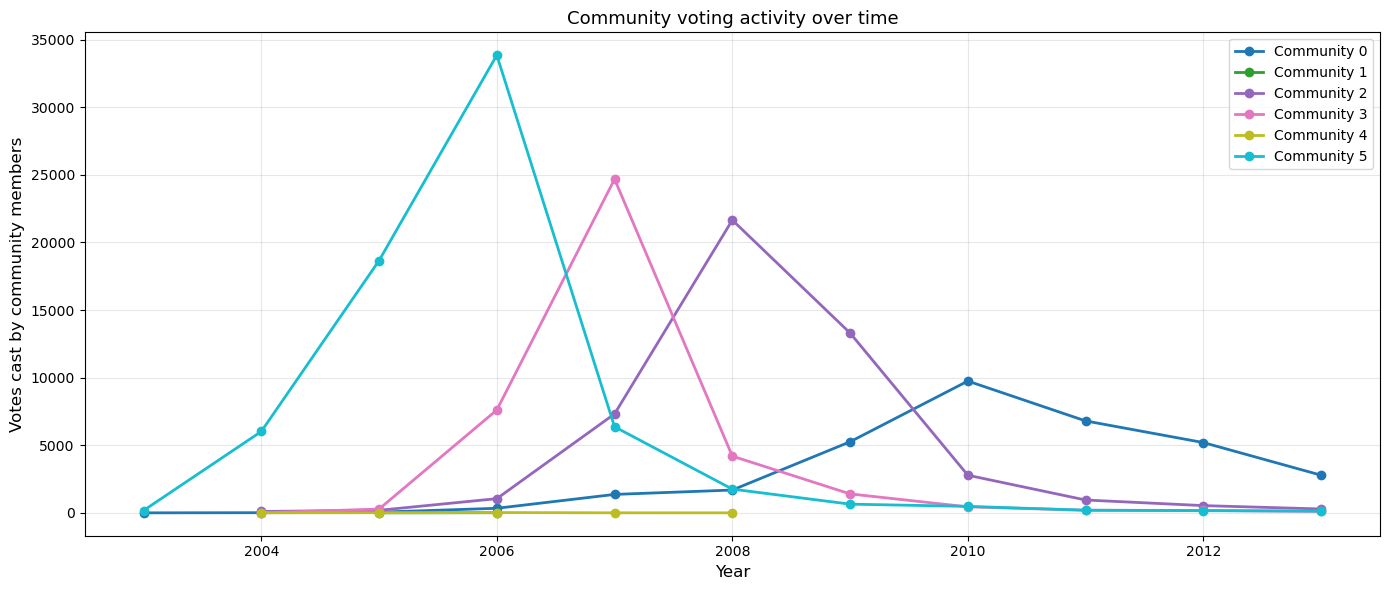

Peak activity year per community:
  Community 0: 2010 (9746 votes)
  Community 1: 2006 (9 votes)
  Community 2: 2008 (21651 votes)
  Community 3: 2007 (24677 votes)
  Community 4: 2006 (22 votes)
  Community 5: 2006 (33842 votes)


In [28]:
# Only keep votes where the voter belongs to a known community
df_comm = df[df["voter_community"].notna()].copy()
df_comm["voter_community"] = df_comm["voter_community"].astype(int)

# Count votes cast per community per year
comm_year = (
    df_comm.groupby(["year", "voter_community"])
    .size()
    .reset_index(name="votes")
)

fig, ax = plt.subplots(figsize=(14, 6))

for comm in sorted(df_comm["voter_community"].unique()):
    subset = comm_year[comm_year["voter_community"] == comm]
    ax.plot(
        subset["year"], subset["votes"],
        marker="o", linewidth=2, label=f"Community {comm}",
        color=COMM_COLORS.get(comm, "#aaaaaa")
    )

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Votes cast by community members", fontsize=12)
ax.set_title("Community voting activity over time", fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("temporal_community_activity.png", dpi=150)
plt.show()

# Also print peak year per community
print("Peak activity year per community:")
for comm in sorted(df_comm["voter_community"].unique()):
    subset = comm_year[comm_year["voter_community"] == comm]
    peak = subset.loc[subset["votes"].idxmax()]
    print(f"  Community {comm}: {int(peak['year'])} ({int(peak['votes'])} votes)")

Appears that communities might have been created based on activity period. Will now create a graph based on one year, to see if similar patterns emerge or not

Re-parse the raw data to make it available for the year-based graph construction below

In [29]:
data = parse_rfa("wiki-RfA.txt")

Define a modified graph builder that filters votes to a single year before projecting into the voter-voter agreement space

In [30]:
def build_voter_graph_by_year(data, year):
    votes_by_candidate = defaultdict(list)

    for d in data:
        src = d.get("SRC", "").strip()
        tgt = d.get("TGT", "").strip()

        if not src or not tgt:
            continue

        if int(d["YEA"]) != year:
            continue

        vote = int(d["VOT"])

        # skip neutral votes
        if vote == 0:
            continue

        votes_by_candidate[tgt].append((src, vote))

    G = nx.Graph()

    for cand, voter_list in votes_by_candidate.items():
        for (u, vote_u), (v, vote_v) in combinations(voter_list, 2):

            pair_weight = vote_u * vote_v

            if G.has_edge(u, v):
                G[u][v]["weight"] += pair_weight
                G[u][v]["count"] += 1
            else:
                G.add_edge(u, v, weight=pair_weight, count=1)

    for u, v, edge_data in G.edges(data=True):
        edge_data["normalized"] = round(edge_data["weight"] / edge_data["count"], 5)

    return G

Build and inspect the 2013-only voter graph

In [107]:
G_2013 = build_voter_graph_by_year(data, 2013)

print("2013 voter graph")
print("Nodes:", G_2013.number_of_nodes())
print("Edges:", G_2013.number_of_edges())

2013 voter graph
Nodes: 784
Edges: 103014


Building new filtered graph based on agreement in 2013

In [108]:
G_agree_2013 = nx.Graph()

for u, v, d in G_2013.edges(data=True):
    if d["normalized"] > 0:
        G_agree_2013.add_edge(u, v, **d)

print("2013 agreement graph")
print("Nodes:", G_agree_2013.number_of_nodes())
print("Edges:", G_agree_2013.number_of_edges())

2013 agreement graph
Nodes: 783
Edges: 77680


Doing community detection

In [109]:
partition_agree_2013 = community_louvain.best_partition(
    G_agree_2013,
    weight="normalized",
    random_state=42
)

Summarise the community structure found in the 2013 graph

In [110]:
num_communities = len(set(partition_agree_2013.values()))
print("Number of communities:", num_communities)

community_sizes = Counter(partition_agree_2013.values())
print("\nLargest communities:")
for comm, size in community_sizes.most_common(10):
    print(f"Community {comm}: {size} nodes")

Number of communities: 9

Largest communities:
Community 1: 161 nodes
Community 3: 143 nodes
Community 0: 112 nodes
Community 7: 102 nodes
Community 2: 92 nodes
Community 8: 90 nodes
Community 5: 42 nodes
Community 4: 39 nodes
Community 6: 2 nodes


Appears to have fewer communites than before

Attach the 2013 community labels as node attributes so they can be used in downstream analysis

In [111]:
nx.set_node_attributes(G_agree_2013, partition_agree_2013, "community")

Build a node-to-community lookup dictionary for the 2013 partition

In [112]:
node_to_community_2013 = {
    node: attrs["community"]
    for node, attrs in G_agree_2013.nodes(data=True)
    if "community" in attrs
}

print("Nodes with community labels:", len(node_to_community_2013))

Nodes with community labels: 783


Checking amount of texts in each community

In [113]:
texts_by_community_2013 = defaultdict(list)

for r in data:
    src = r.get("SRC", "").strip()
    txt = r.get("TXT", "").strip()
    year = int(r.get("YEA", 0))

    if year != 2013:
        continue

    if not txt:
        continue

    if src in node_to_community_2013:
        comm = node_to_community_2013[src]
        texts_by_community_2013[comm].append(txt)

for comm, texts in texts_by_community_2013.items():
    print(f"Community {comm}: {len(texts)} texts")

Community 0: 452 texts
Community 3: 754 texts
Community 8: 404 texts
Community 2: 423 texts
Community 4: 133 texts
Community 7: 400 texts
Community 5: 199 texts
Community 1: 740 texts
Community 6: 2 texts


As before, building one document for each community

In [114]:
community_ids_2013 = sorted(texts_by_community_2013.keys())
community_documents_2013 = [
    " ".join(texts_by_community_2013[comm])
    for comm in community_ids_2013
]

print("Number of community documents:", len(community_documents_2013))

Number of community documents: 9


Cleaning text

In [115]:
community_documents_2013 = [
    " ".join(clean_text(t) for t in texts_by_community_2013[c])
    for c in community_ids_2013
]

Calculates TF-IDF

In [116]:
vectorizer = TfidfVectorizer(
    stop_words=None,
    max_df=0.9,
    min_df=1,
    ngram_range=(1, 2)        
)

X = vectorizer.fit_transform(community_documents_2013)
terms = vectorizer.get_feature_names_out()

tfidf_df_2013 = pd.DataFrame(
    X.toarray(),
    index=[f"community_{c}" for c in community_ids_2013],
    columns=terms
)

Finds top TF-IDF words for each 2013 community

In [117]:
for comm in community_ids_2013:
    row = tfidf_df_2013.loc[f"community_{comm}"]
    top_terms_2013 = row.sort_values(ascending=False).head(5)

    print(f"\nTop TF-IDF terms for community {comm}:")
    for term, score in top_terms_2013.items():
        print(f"{term}: {score:.4f}")


Top TF-IDF terms for community 0:
tools: 0.2437
work: 0.1806
concerns: 0.1692
experience: 0.1434
content: 0.1290

Top TF-IDF terms for community 1:
tools: 0.3006
reason: 0.1595
work: 0.1411
seems: 0.1268
opposes: 0.1145

Top TF-IDF terms for community 2:
tools: 0.1844
concerns: 0.1614
work: 0.1421
great: 0.1229
experience: 0.1153

Top TF-IDF terms for community 3:
work: 0.1627
tools: 0.1568
concerns: 0.1490
content: 0.1470
experience: 0.1411

Top TF-IDF terms for community 4:
editors: 0.1487
project: 0.1439
tools: 0.1439
content: 0.1343
work: 0.1295

Top TF-IDF terms for community 5:
work: 0.1537
concerns: 0.1450
tools: 0.1406
contributions: 0.1274
content: 0.1186

Top TF-IDF terms for community 6:
country: 0.4158
time sign: 0.2461
supporting country: 0.2461
sign posts: 0.2461
representative advocacy: 0.2461

Top TF-IDF terms for community 7:
work: 0.2022
tools: 0.1986
experience: 0.1228
reason: 0.1192
seems: 0.1192

Top TF-IDF terms for community 8:
work: 0.1799
tools: 0.1587
concern

Wordclouds for 2013 communities

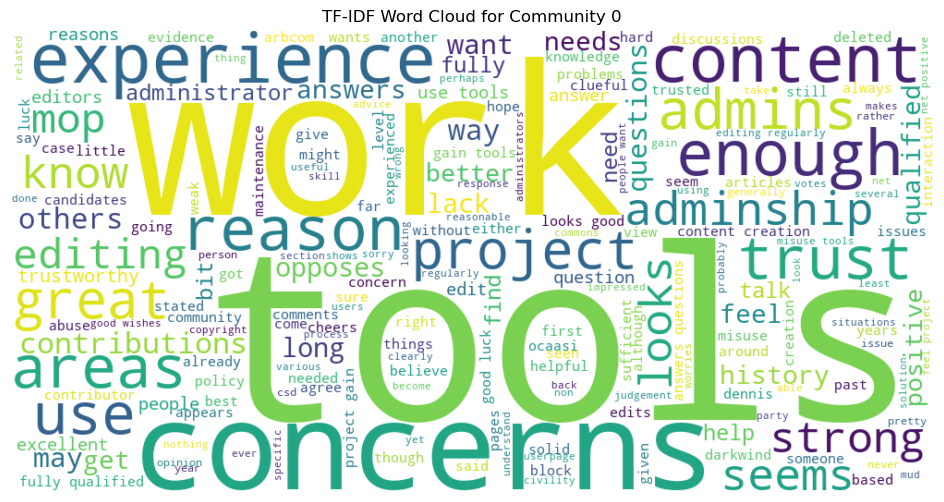

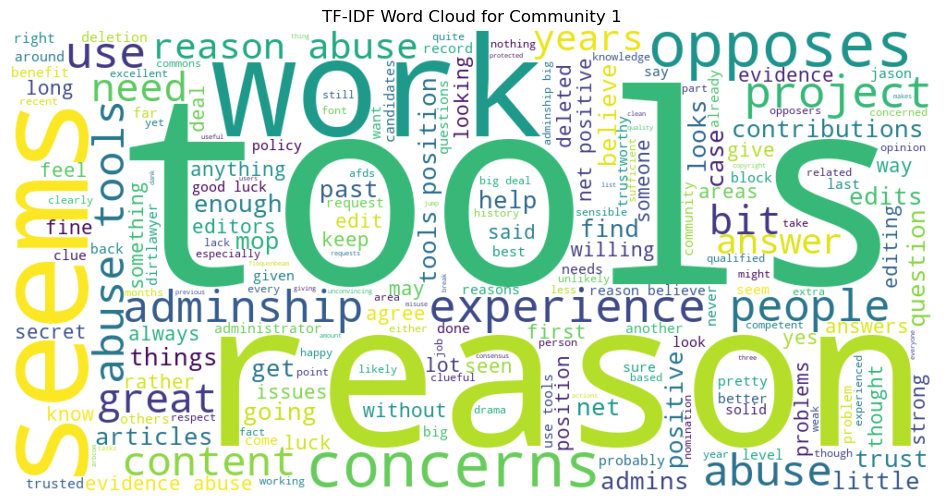

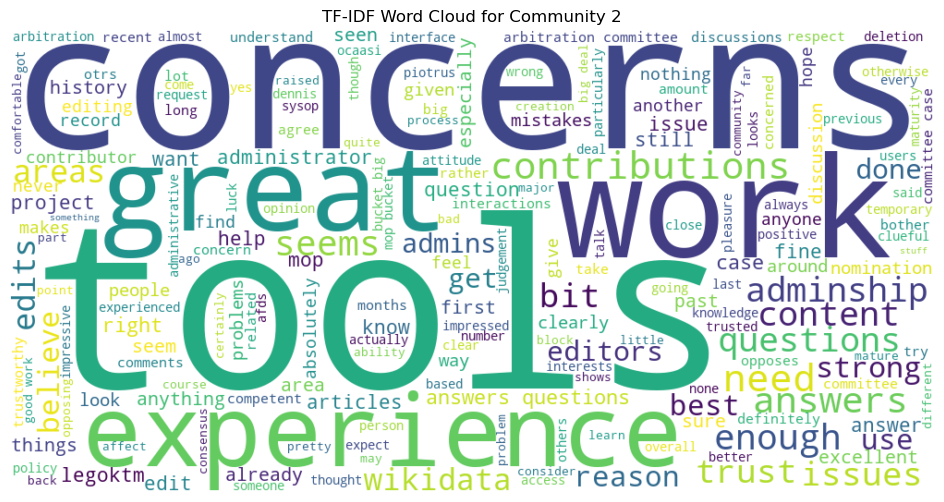

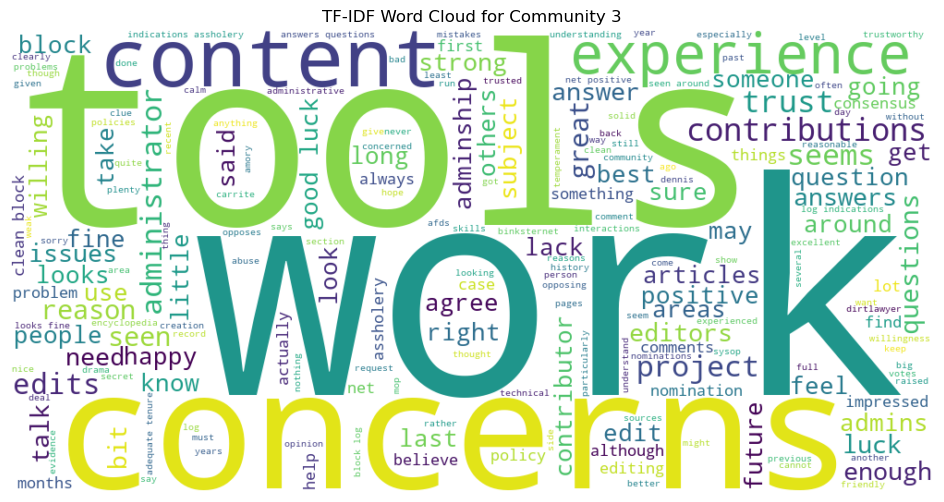

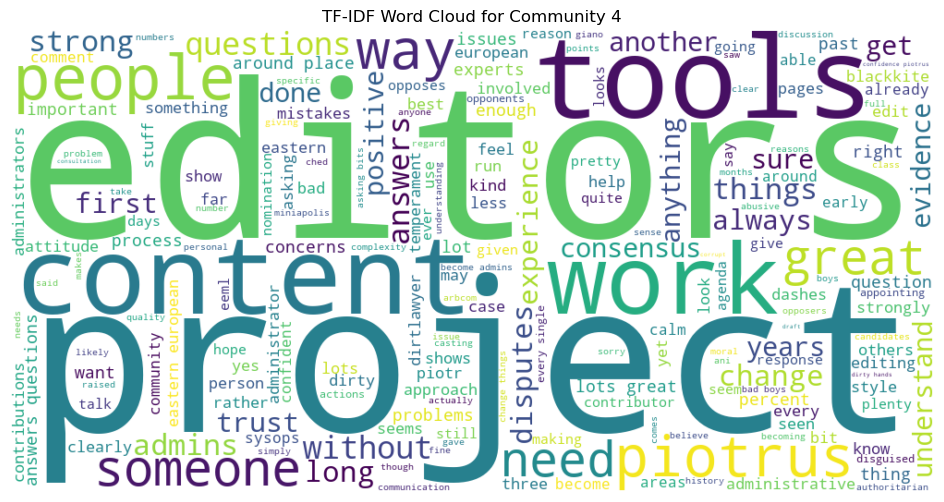

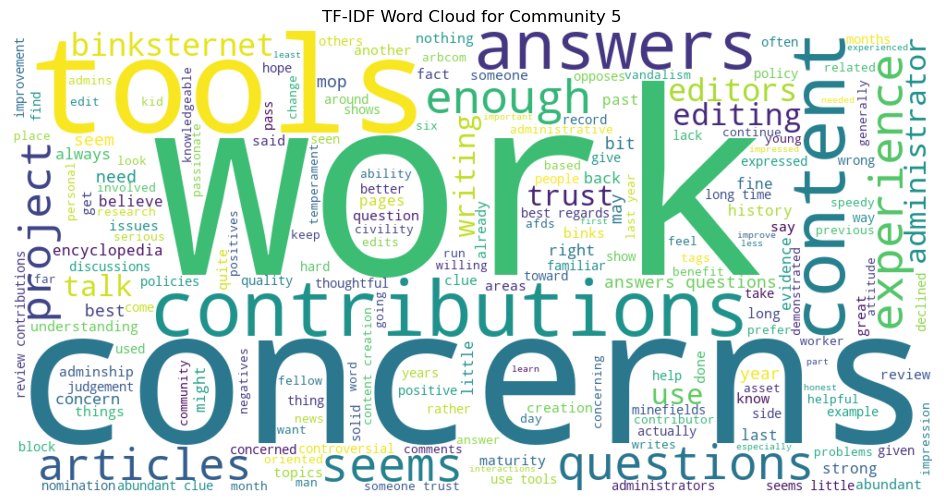

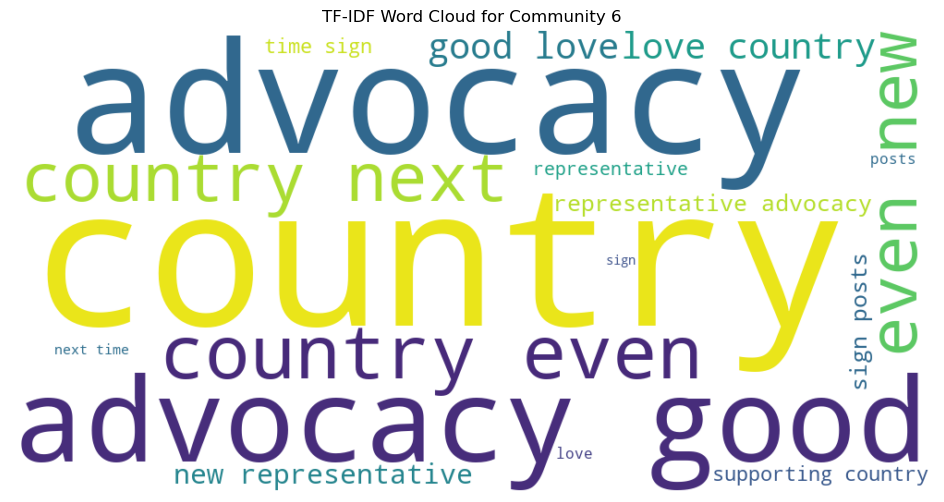

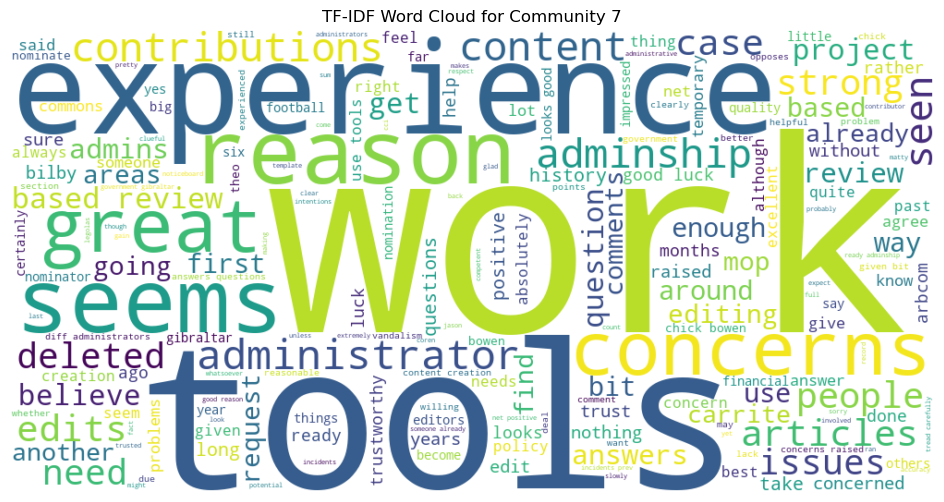

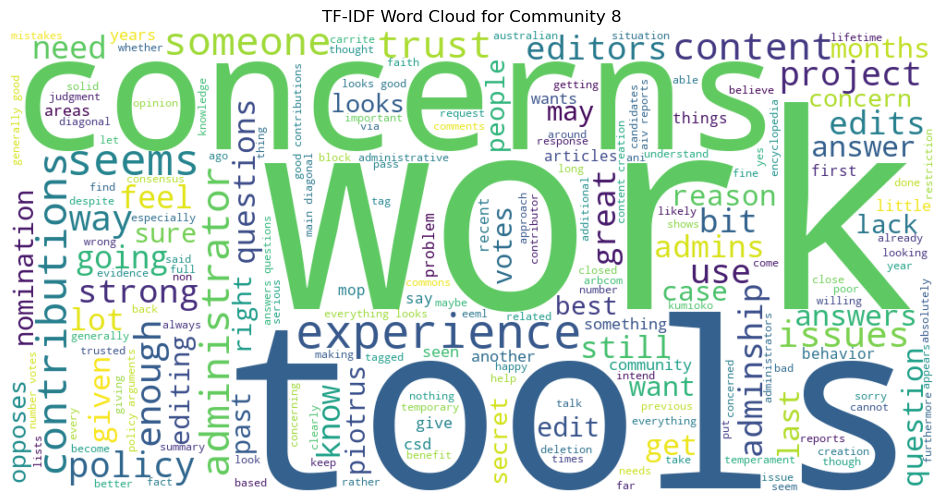

In [ ]:
for c in community_ids_2013:
    row = tfidf_df_2013.loc[f"community_{c}"]
    
    freq_dict = row[row > 0].to_dict()

    wc = WordCloud(
        width=1000,
        height=500,
        background_color="white"
    ).generate_from_frequencies(freq_dict)

    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"TF-IDF Word Cloud for Community {c}")
    plt.savefig(f"community_{c}_2013_wordcloud.png", dpi=150)
    plt.show()

Build a flat record list for 2013 votes, attaching the 2013 community label to each voter

In [119]:
records_2013 = []

for r in data:
    voter = r.get("SRC", "").strip()
    candidate = r.get("TGT", "").strip()

    if not voter or not candidate:
        continue

    records_2013.append({
        "voter": voter,
        "candidate": candidate,
        "vote": int(r.get("VOT", 0)),
        "result": int(r.get("RES", 0)),
        "year": int(r.get("YEA", 0)),
        "voter_community": partition_agree_2013.get(voter)
    })

df_2013_comm = pd.DataFrame(records_2013)

df_2013_comm = df_2013_comm[df_2013_comm["year"] == 2013].copy()
df_2013_comm = df_2013_comm[df_2013_comm["voter_community"].notna()].copy()
df_2013_comm["voter_community"] = df_2013_comm["voter_community"].astype(int)

print(df_2013_comm.head())
print("Number of votes:", len(df_2013_comm))
print("Communities:", sorted(df_2013_comm["voter_community"].unique()))

        voter candidate  vote  result  year  voter_community
0   Steel1943       BDD     1       1  2013                0
1  Cuchullain       BDD     1       1  2013                0
2   INeverCry       BDD     1       1  2013                3
3   Cncmaster       BDD     1       1  2013                3
4  Miniapolis       BDD     1       1  2013                8
Number of votes: 3545
Communities: [0, 1, 2, 3, 4, 5, 6, 7, 8]


Aggregate vote counts by year and community to compare activity levels across communities

In [120]:
comm_year_2013 = (
    df_2013_comm
    .groupby(["year", "voter_community"])
    .size()
    .reset_index(name="votes")
)

print(comm_year_2013)

   year  voter_community  votes
0  2013                0    454
1  2013                1    763
2  2013                2    425
3  2013                3    755
4  2013                4    133
5  2013                5    203
6  2013                6      2
7  2013                7    405
8  2013                8    405


Visualise the vote counts per 2013 community as a bar chart

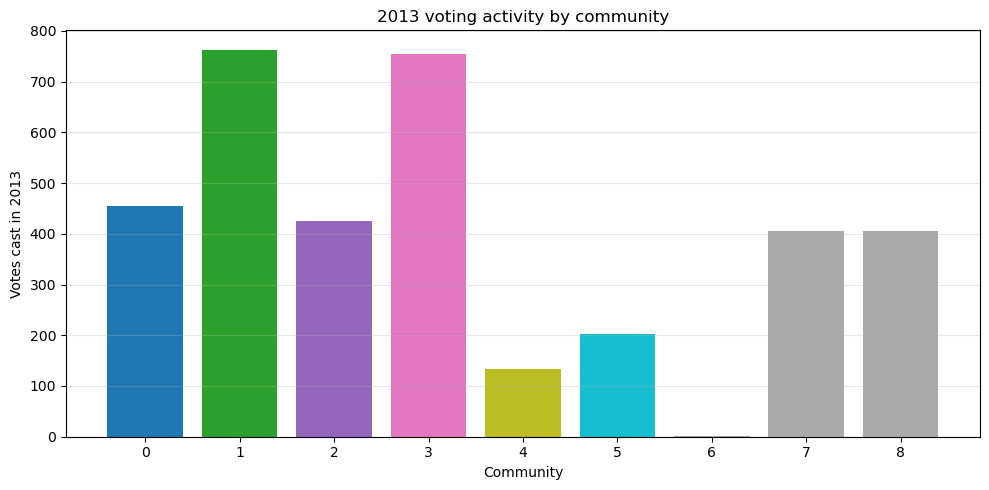

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

for comm in sorted(df_2013_comm["voter_community"].unique()):
    subset = comm_year_2013[comm_year_2013["voter_community"] == comm]

    ax.bar(
        str(comm),
        subset["votes"].iloc[0],
        label=f"Community {comm}",
        color=COMM_COLORS.get(comm, "#aaaaaa")
    )

ax.set_xlabel("Community")
ax.set_ylabel("Votes cast in 2013")
ax.set_title("2013 voting activity by community")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("community_activity_2013.png", dpi=150)
plt.show()

Parse the full date field for 2013 voters to enable monthly-resolution activity analysis

In [122]:
records_2013 = []

for r in data:
    voter = r.get("SRC", "").strip()

    if voter not in partition_agree_2013:
        continue

    txt_date = r.get("DAT", "").strip()

    try:
        date = pd.to_datetime(
            txt_date,
            format="%H:%M, %d %B %Y"
        )
    except:
        continue

    # TRUE filtering based on actual parsed datetime
    if date.year != 2013:
        continue

    records_2013.append({
        "date": date,
        "community": partition_agree_2013[voter]
    })

df_time = pd.DataFrame(records_2013)

Aggregate votes by month and community for the time-series plot

In [123]:
df_time["month"] = df_time["date"].dt.to_period("M")

comm_month = (
    df_time.groupby(["month", "community"])
    .size()
    .reset_index(name="votes")
)

comm_month["month"] = comm_month["month"].astype(str)

Plot monthly voting activity per community across the 2013 election period

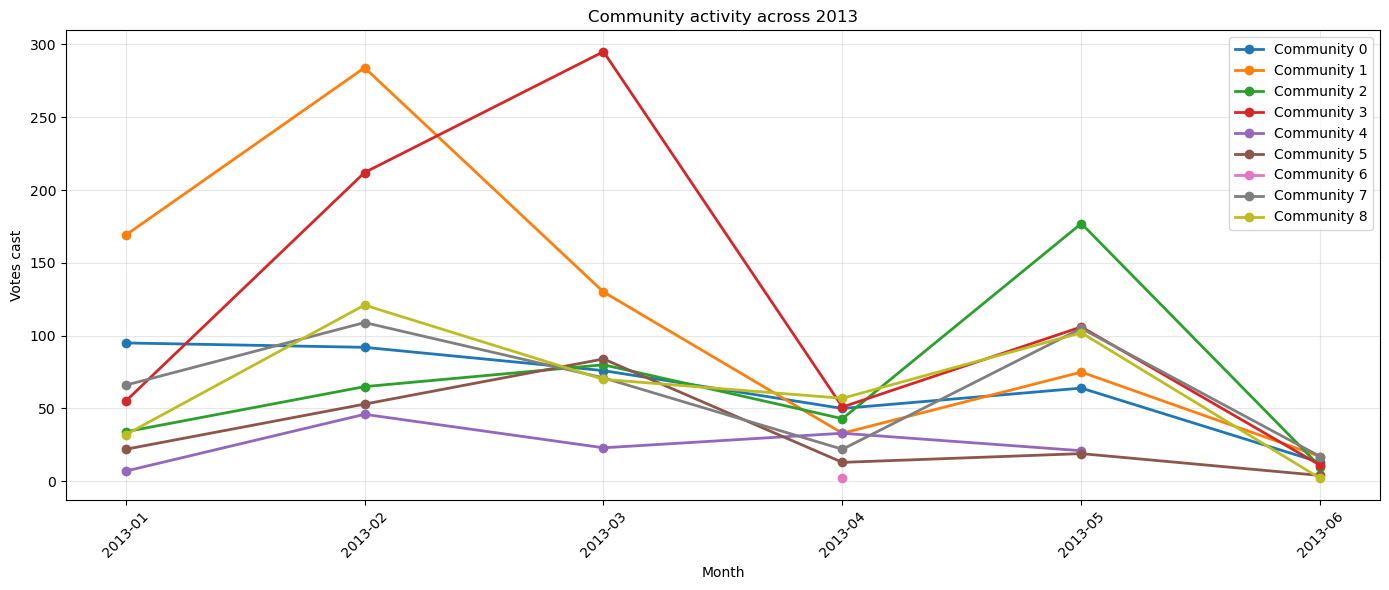

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

for comm in sorted(comm_month["community"].unique()):
    subset = comm_month[comm_month["community"] == comm]

    ax.plot(
        subset["month"],
        subset["votes"],
        marker="o",
        linewidth=2,
        label=f"Community {comm}"
    )

ax.set_xlabel("Month")
ax.set_ylabel("Votes cast")
ax.set_title("Community activity across 2013")

plt.xticks(rotation=45)
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig("community_activity_2013_monthly.png", dpi=150)
plt.show()